In [34]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# Display settings (optional but useful)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
%matplotlib inline
sns.set(style="whitegrid")

In [35]:
# Load dataset (MongoDB থেকে save করা CSV হলে)
df = pd.read_csv("final_sleep_dataDev.csv")

# Basic check
df.head()

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,What are the main reasons you sleep late?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,Do you experience any of the following side effects from late sleeping?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment
0,18-30,83.0,5.1,Male,Student,10 PM - 12 AM,6 AM - 8 AM,12 AM - 2 AM,8 AM - 10 AM,15-30 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Rarely,Never,Sometimes,No,Fatigue ;Decreased academic or work performanc...,Sometimes,Caffeine or other stimulants ;Exercise ;Others,4
1,18-30,68.0,5.8,Male,Student,After 2 AM,8 AM - 10 AM,After 2 AM,After 10 AM,15-30 minutes,4-6 hours,Study & Exam Purpose;Social Media/Internet;Ent...,Rarely,Never,Never,Asthma,Difficulty concentrating ;Mood swings or irrit...,Sometimes,Naps during the day ;Caffeine or other stimula...,4
2,18-30,50.0,5.8,Male,Student,12 AM - 2 AM,8 AM - 10 AM,12 AM - 2 AM,8 AM - 10 AM,15-30 minutes,6-8 hours,professional Work;Study & Exam Purpose;Social ...,Never,Never,Rarely,Depression,Fatigue ;Mood swings or irritability ;Decrease...,Never,Naps during the day ;Exercise,4
3,18-30,70.0,5.5,Female,Student,12 AM - 2 AM,6 AM - 8 AM,After 2 AM,After 10 AM,More than 60 minutes,4-6 hours,Social Media/Internet;Entertainment (TV;movies...,Always,Sometimes,Sometimes,Depression,Fatigue ;Difficulty concentrating ;Mood swings...,Always,Exercise,3
4,18-30,70.0,5.6,Male,Student,12 AM - 2 AM,6 AM - 8 AM,12 AM - 2 AM,8 AM - 10 AM,Less than 15 minutes,6-8 hours,Study & Exam Purpose;Social Media/Internet;Str...,Sometimes,Rarely,Never,Anxiety Disorders,Fatigue ;Difficulty concentrating ;Mood swings...,Often,Naps during the day ;Exercise ;Others,4


In [36]:
df.describe()

,What is your weight,Your Height,How would you rate the comfort of your sleeping environment
count,52609.000000,52604.000000,52610.000000
mean,65.265782,5.450064,3.488956
std,11.048847,0.597232,1.045761
min,5.100000,4.000000,1.000000
25%,58.200000,5.150000,3.000000
50%,65.100000,5.450000,4.000000
75%,72.000000,5.740000,4.000000
max,934.000000,59.000000,5.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52610 entries, 0 to 52609
Data columns (total 20 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Your Age                                                                    52610 non-null  object 
 1   What is your weight                                                         52609 non-null  float64
 2   Your Height                                                                 52604 non-null  float64
 3   What is your gender?                                                        52609 non-null  object 
 4   What is your occupation?                                                    52609 non-null  object 
 5   What time do you usually go to bed?                                         52610 non-null  object 
 6   What time do you usually wake up on working da

In [38]:
# Check missing values (count + percentage)
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
What strategies do you use to cope with the side effects of late sleeping?,7843,14.907812
What are the main reasons you sleep late?,2356,4.478236
Do you experience any of the following side effects from late sleeping?,1046,1.988215
Do you have any medical conditions that might affect your sleep?,336,0.638662
How often do you find it hard to concentrate due to lack of sleep?,27,0.051321
Your Height,6,0.011405
What is your gender?,1,0.001901
What is your occupation?,1,0.001901
How long does it take you to fall asleep after going to bed?,1,0.001901
What is your weight,1,0.001901


In [39]:
# Normalize common dirty missing tokens
missing_tokens = ['na', 'n/a', 'none', 'null', 'nan', '', ' ']

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace(missing_tokens, np.nan)

In [40]:
# Drop columns with >40% missing
threshold = 40
cols_to_drop = missing_df[missing_df['Missing %'] > threshold].index.tolist()

df = df.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)

Dropped columns: []


In [41]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [42]:
print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [43]:
# Numerical & Categorical feature separation

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['What is your weight', 'Your Height', 'How would you rate the comfort of your sleeping environment']
We have 17 categorical features: ['Your Age', 'What is your gender?', 'What is your occupation?', 'What time do you usually go to bed?', 'What time do you usually wake up on working days?', 'What time do you usually go to bed on weekends?', 'What time do you usually wake up on weekends?', 'How long does it take you to fall asleep after going to bed?', 'How many hours of sleep do you get on average per night?', 'What are the main reasons you sleep late?', 'Do you have difficulty falling asleep?', 'Do you experience breathing difficulties while sleeping', 'Do you experience restless legs or involuntary movements during sleep?', 'Do you have any medical conditions that might affect your sleep?', 'Do you experience any of the following side effects from late sleeping?', 'How often do you find it hard to concentrate due to lack of sleep?', 'What strategies do y

In [44]:
# Proportion of values in categorical columns (percentage)

for col in categorical_features:
    print(f"Column: {col}")
    print(df[col].value_counts(normalize=True) * 100)
    print("-" * 50)

Column: Your Age
Your Age
18-30       44.662612
under 18    24.567573
31-50       20.345942
above 50    10.423874
Name: proportion, dtype: float64
--------------------------------------------------
Column: What is your gender?
What is your gender?
female               49.992397
male                 48.007983
prefer not to say     1.999620
Name: proportion, dtype: float64
--------------------------------------------------
Column: What is your occupation?
What is your occupation?
student                 40.788823
working professional    30.766014
others                  11.030222
freelancing             10.157765
unemployment             5.303174
housewife                1.954001
Name: proportion, dtype: float64
--------------------------------------------------
Column: What time do you usually go to bed?
What time do you usually go to bed?
12 am - 2 am     44.225432
10 pm - 12 am    30.136856
after 2 am       15.299373
before 10 pm     10.338339
Name: proportion, dtype: float64
--------

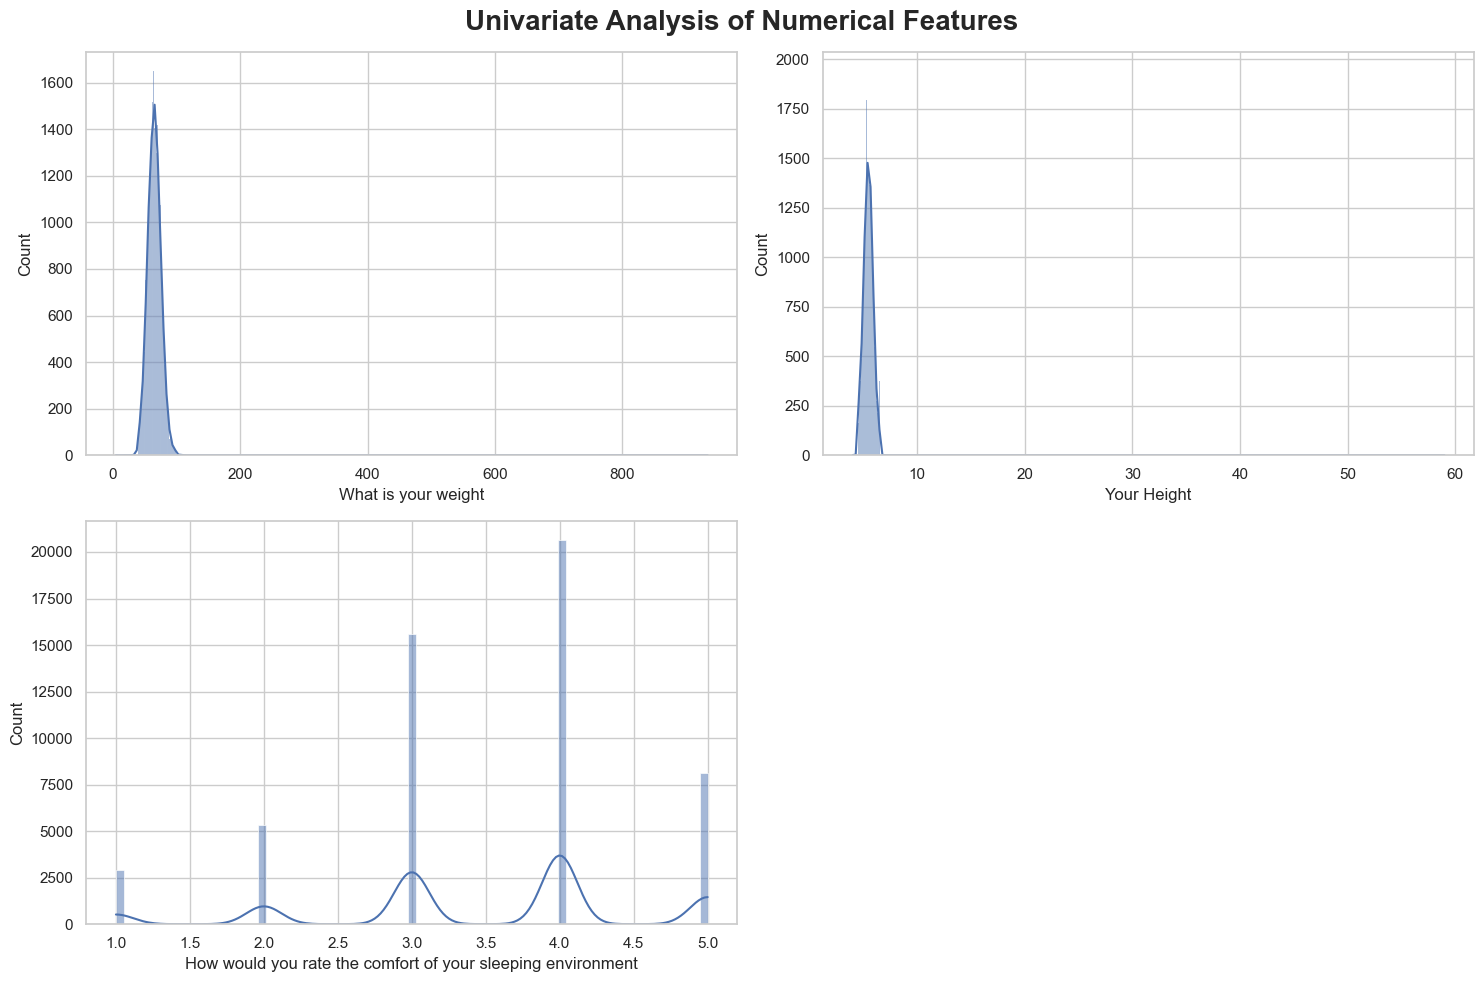

In [45]:
# Univariate Analysis of Numerical Features

plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold')

for i in range(len(numeric_features)):
    plt.subplot(2, 2, i + 1)  # adjust grid if needed
    sns.histplot(x=df[numeric_features[i]], kde=True)
    plt.xlabel(numeric_features[i])

plt.tight_layout()
plt.show()

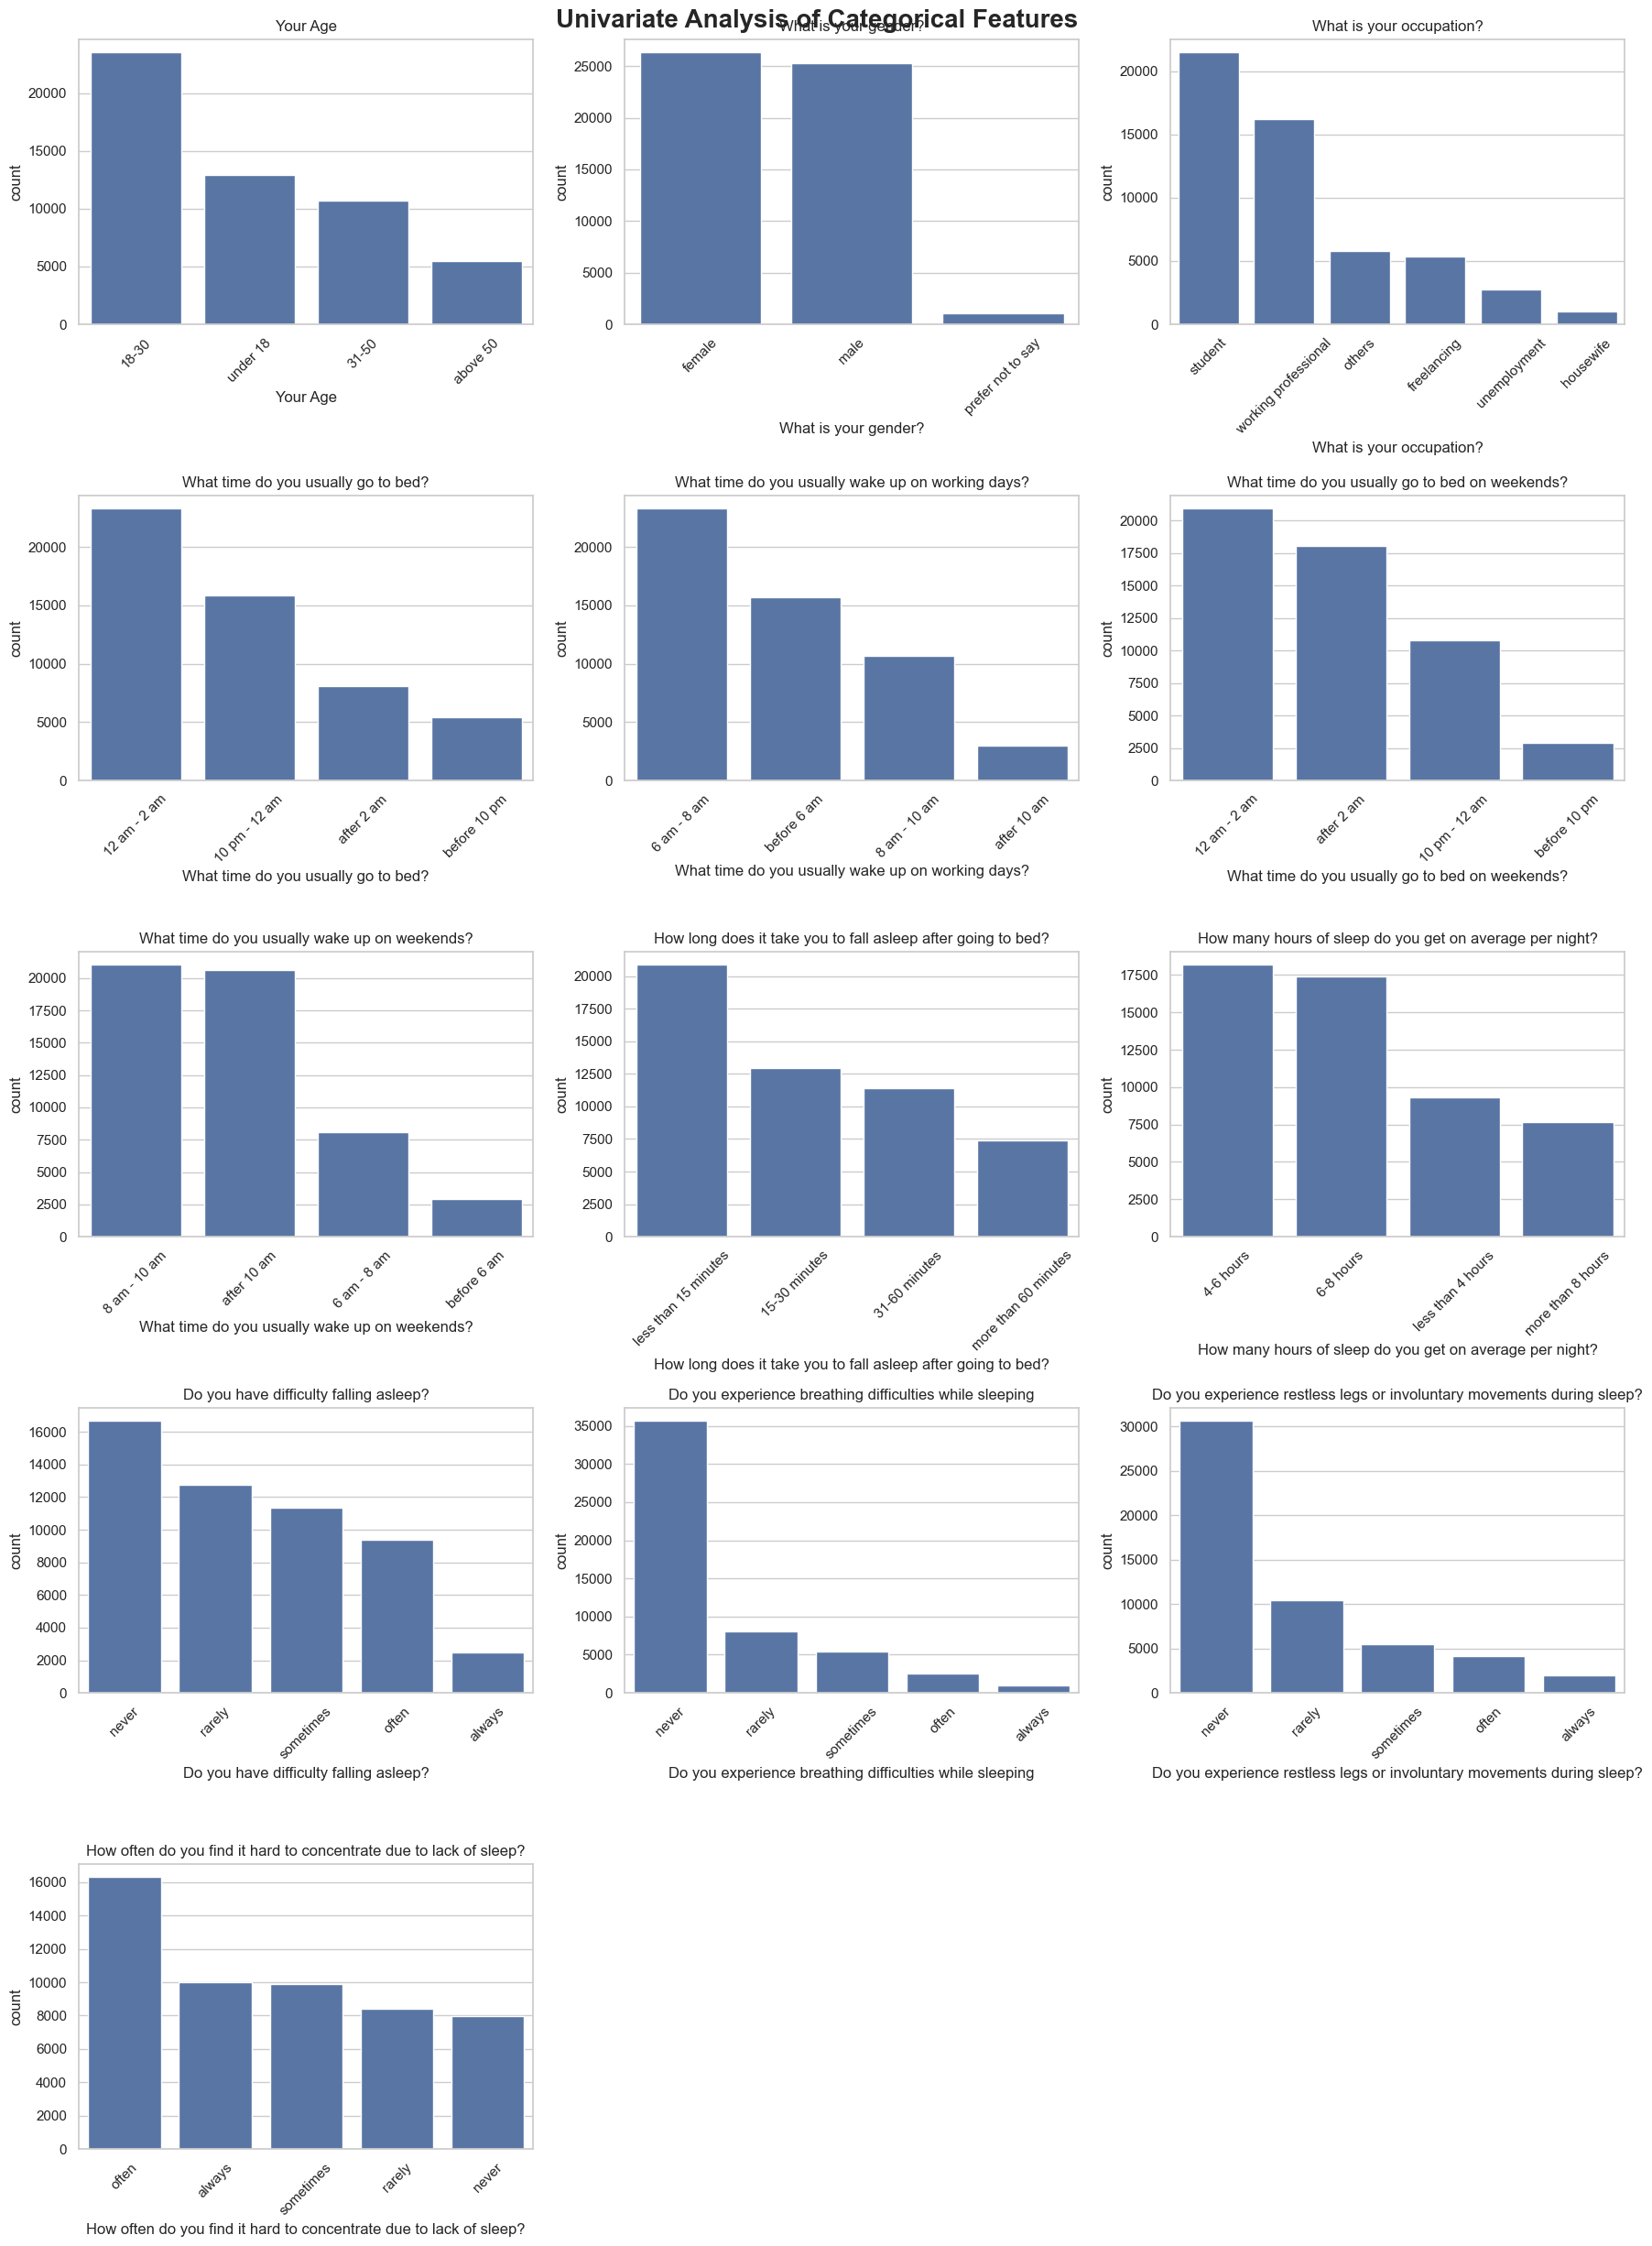

In [46]:
# Fixed version (dynamic subplot indexing)

valid_cols = [col for col in categorical_features if df[col].nunique() <= 20]

n_cols = 3
n_rows = int(np.ceil(len(valid_cols) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold')

for i, col in enumerate(valid_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

In [47]:
# Multivariate Analysis: Discrete vs Continuous Features

discrete_features = [feature for feature in numeric_features if df[feature].nunique() <= 25]
continuous_features = [feature for feature in numeric_features if df[feature].nunique() > 25]

print(f"We have {len(discrete_features)} discrete features: {discrete_features}")
print(f"We have {len(continuous_features)} continuous features: {continuous_features}")

We have 1 discrete features: ['How would you rate the comfort of your sleeping environment']
We have 2 continuous features: ['What is your weight', 'Your Height']


In [48]:
df.head()

,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,What are the main reasons you sleep late?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,Do you experience any of the following side effects from late sleeping?,How often do you find it hard to concentrate due to lack of sleep?,What strategies do you use to cope with the side effects of late sleeping?,How would you rate the comfort of your sleeping environment
0,18-30,83.0,5.1,male,student,10 pm - 12 am,6 am - 8 am,12 am - 2 am,8 am - 10 am,15-30 minutes,6-8 hours,study & exam purpose;social media/internet;ent...,rarely,never,sometimes,no,fatigue ;decreased academic or work performanc...,sometimes,caffeine or other stimulants ;exercise ;others,4
1,18-30,68.0,5.8,male,student,after 2 am,8 am - 10 am,after 2 am,after 10 am,15-30 minutes,4-6 hours,study & exam purpose;social media/internet;ent...,rarely,never,never,asthma,difficulty concentrating ;mood swings or irrit...,sometimes,naps during the day ;caffeine or other stimula...,4
2,18-30,50.0,5.8,male,student,12 am - 2 am,8 am - 10 am,12 am - 2 am,8 am - 10 am,15-30 minutes,6-8 hours,professional work;study & exam purpose;social ...,never,never,rarely,depression,fatigue ;mood swings or irritability ;decrease...,never,naps during the day ;exercise,4
3,18-30,70.0,5.5,female,student,12 am - 2 am,6 am - 8 am,after 2 am,after 10 am,more than 60 minutes,4-6 hours,social media/internet;entertainment (tv;movies...,always,sometimes,sometimes,depression,fatigue ;difficulty concentrating ;mood swings...,always,exercise,3
4,18-30,70.0,5.6,male,student,12 am - 2 am,6 am - 8 am,12 am - 2 am,8 am - 10 am,less than 15 minutes,6-8 hours,study & exam purpose;social media/internet;str...,sometimes,rarely,never,anxiety disorders,fatigue ;difficulty concentrating ;mood swings...,often,naps during the day ;exercise ;others,4


In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# -----------------------------
# 1. Clean text (important step)
# -----------------------------
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype(str).str.strip()

# -----------------------------
# 2. Multi-label columns (split + one-hot)
# -----------------------------
multi_cols = [
    'What are the main reasons you sleep late?',
    'Do you experience any of the following side effects from late sleeping?',
    'What strategies do you use to cope with the side effects of late sleeping?'
]

multi_encoded_dfs = []

for col in multi_cols:
    temp = df_encoded[col].str.get_dummies(sep=';')
    
    # Clean column names
    temp.columns = [c.strip().replace(" ", "").replace("/", "_").replace(",", "") for c in temp.columns]
    
    multi_encoded_dfs.append(temp)

# Concatenate all multi-label encodings
multi_encoded = pd.concat(multi_encoded_dfs, axis=1)

# Drop original multi columns
df_encoded.drop(columns=multi_cols, inplace=True)

# Add encoded multi columns
df_encoded = pd.concat([df_encoded, multi_encoded], axis=1)

# -----------------------------
# 3. Label Encoding (remaining categorical)
# -----------------------------
label_encoder = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include='object').columns

for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# -----------------------------
# 4. Final output
# -----------------------------
print("Final Encoded Shape:", df_encoded.shape)
df_encoded.head()

Final Encoded Shape: (52610, 50)


,Your Age,What is your weight,Your Height,What is your gender?,What is your occupation?,What time do you usually go to bed?,What time do you usually wake up on working days?,What time do you usually go to bed on weekends?,What time do you usually wake up on weekends?,How long does it take you to fall asleep after going to bed?,How many hours of sleep do you get on average per night?,Do you have difficulty falling asleep?,Do you experience breathing difficulties while sleeping,Do you experience restless legs or involuntary movements during sleep?,Do you have any medical conditions that might affect your sleep?,How often do you find it hard to concentrate due to lack of sleep?,How would you rate the comfort of your sleeping environment,entertainment(tv,games),insomniaorothersleepdisorder,movies,others,professionalwork,socialmedia_internet,stressoranxiety,study&exampurpose,backpain,backpain,decreasedacademicorworkperformance,decreasedacademicorworkperformance,difficultyconcentrating,difficultyconcentrating,fatigue,fatigue,healthissues,healthissues),moodswingsorirritability,moodswingsorirritability,others,others,caffeineorotherstimulants,caffeineorotherstimulants,exercise,exercise,napsduringtheday,napsduringtheday,others,others,relaxationtechniques,relaxationtechniques)
0,0,83.0,5.1,1,3,0,0,1,1,0,1,3,1,4,52,4,4,1,1,1,1,0,0,1,1,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0
1,0,68.0,5.8,1,3,2,1,2,2,0,0,3,1,1,7,4,4,1,1,0,1,0,0,1,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1
2,0,50.0,5.8,1,3,1,1,1,1,0,1,1,1,3,20,1,4,1,1,0,1,0,1,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0
3,0,70.0,5.5,0,3,1,0,2,2,3,0,0,4,4,20,0,3,1,1,1,1,0,0,1,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0
4,0,70.0,5.6,1,3,1,0,1,1,2,1,4,3,1,2,2,4,0,0,0,0,0,0,1,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [50]:
def categorize_conditions(condition):
    condition = str(condition).lower().strip()

    no_conditions = ['no', 'none', 'nothing', 'negative', 'na', 'না', 'নাহ', 
                     'no disease', 'nope', 'no.', 'no medical condition']
    
    if any(k in condition for k in no_conditions):
        return 'No Condition'

    sleep_respiratory = ['asthma', 'sleep apnea', 'bronchitis', 'hypersomnia',
                         'narcolepsy', 'sleep paralysis', 'deviated septum']
    
    if any(k in condition for k in sleep_respiratory):
        return 'Sleep/Respiratory Disorders'

    health_issues = ['diabetes', 'thyroid', 'heart', 'blood pressure',
                     'stroke', 'hypertension', 'arthritis', 'kidney',
                     'cancer', 'prostate', 'gerd', 'migraine']
    
    if any(k in condition for k in health_issues):
        return 'Health Issues'

    mental_health = ['anxiety', 'stress', 'depression', 'pain', 'tension', 'ocd']
    
    if any(k in condition for k in mental_health):
        return 'Mental Health Issues'

    return 'Others'


# Apply categorization
df['Medical Condition Category'] = df[
    'Do you have any medical conditions that might affect your sleep?'
].apply(categorize_conditions)

In [51]:
df = df.drop(
    columns=['Do you have any medical conditions that might affect your sleep?'],
    errors='ignore'
)

In [52]:

df_chi = df.copy()

In [53]:
categorical_cols = df_chi.select_dtypes(include='object').columns.tolist()

# remove multi-label columns (important)
remove_cols = [
    'What are the main reasons you sleep late?',
    'Do you experience any of the following side effects from late sleeping?',
    'What strategies do you use to cope with the side effects of late sleeping?'
]

categorical_cols = [col for col in categorical_cols if col not in remove_cols]

In [54]:
from scipy.stats import chi2_contingency

target = 'Medical Condition Category'
results = []

for col in categorical_cols:
    
    if col == target:
        continue

    try:
        temp = df_chi[[col, target]].dropna()

        if temp[col].nunique() <= 1:
            continue

        contingency = pd.crosstab(temp[col], temp[target])

        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue

        p_value = chi2_contingency(contingency)[1]

        if p_value < 0.05:
            results.append((col, 'Significant'))
        else:
            results.append((col, 'Not Significant'))

    except:
        continue

chi2_df = pd.DataFrame(results, columns=['Feature', 'Relation'])
chi2_df.sort_values(by='Relation', ascending=False)

,Feature,Relation
4,What time do you usually wake up on working days?,Significant
5,What time do you usually go to bed on weekends?,Significant
6,What time do you usually wake up on weekends?,Significant
9,Do you have difficulty falling asleep?,Significant
10,Do you experience breathing difficulties while...,Significant
11,Do you experience restless legs or involuntary...,Significant
0,Your Age,Not Significant
1,What is your gender?,Not Significant
2,What is your occupation?,Not Significant
3,What time do you usually go to bed?,Not Significant


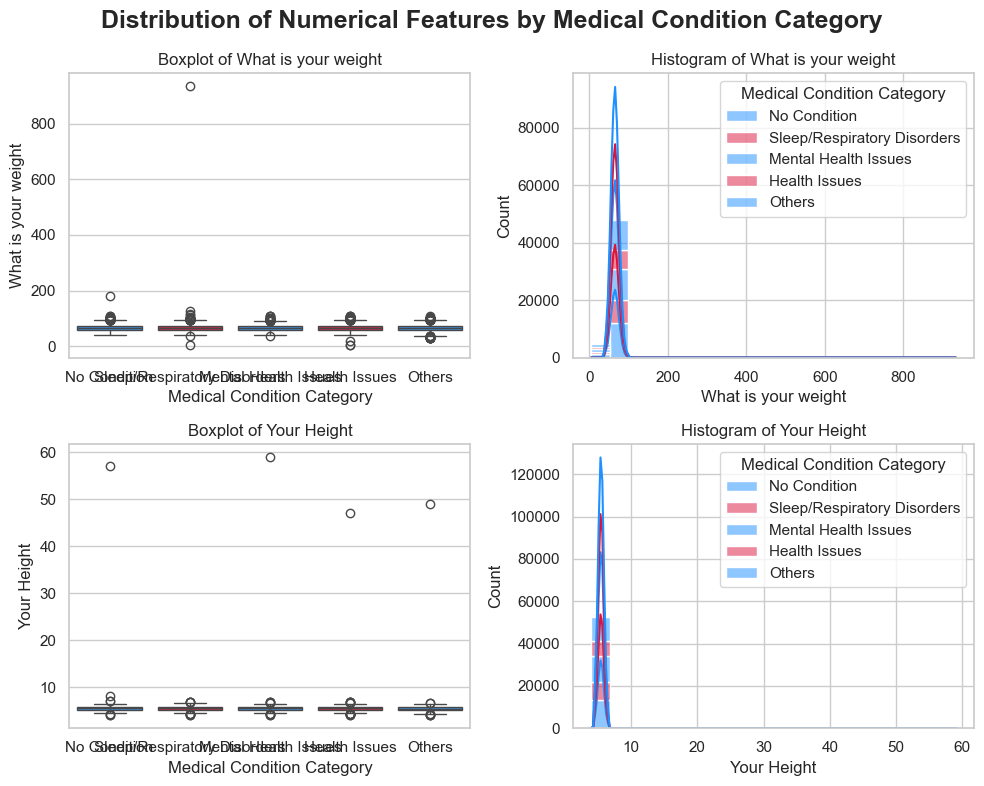

In [55]:
clr = ["#1E90FF", "#DC143C"]

target = 'Medical Condition Category'

fig, ax = plt.subplots(len(continuous_features), 2, figsize=(10, 4*len(continuous_features)))

fig.suptitle(
    'Distribution of Numerical Features by Medical Condition Category',
    fontsize=18, fontweight='bold'
)

for i, col in enumerate(continuous_features):

    # Boxplot
    sns.boxplot(data=df, x=target, y=col, palette=clr, ax=ax[i, 0])
    ax[i, 0].set_title(f'Boxplot of {col}', fontsize=12)

    # Histogram
    sns.histplot(data=df, x=col, hue=target, bins=20, kde=True,
                 multiple='stack', palette=clr, ax=ax[i, 1])
    ax[i, 1].set_title(f'Histogram of {col}', fontsize=12)

plt.tight_layout()
plt.show()

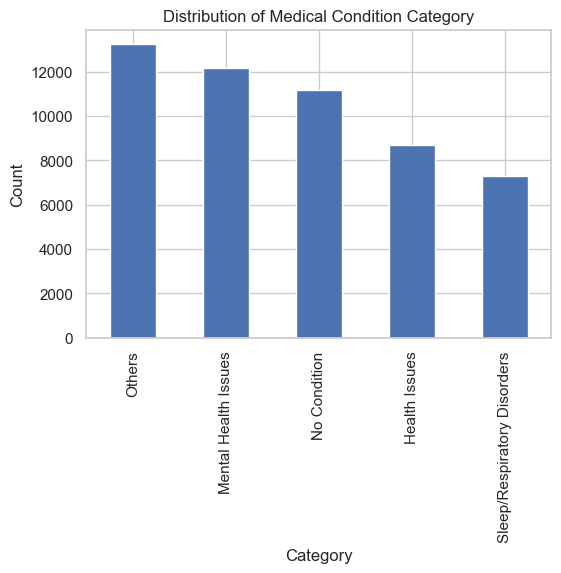

In [56]:
plt.figure(figsize=(6,4))
df['Medical Condition Category'].value_counts().plot(kind='bar')
plt.title("Distribution of Medical Condition Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

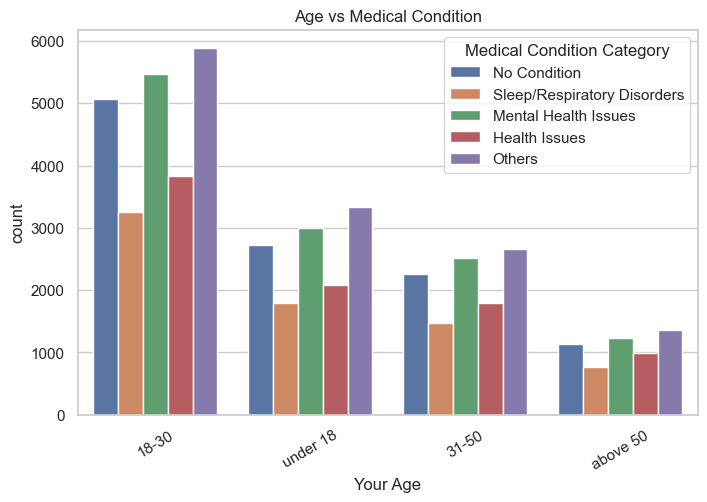

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x='Your Age', hue='Medical Condition Category', data=df)
plt.title("Age vs Medical Condition")
plt.xticks(rotation=30)
plt.show()

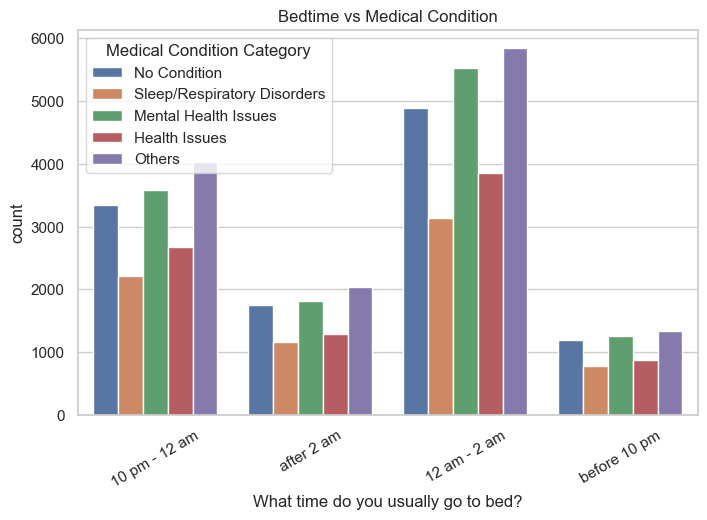

In [58]:
plt.figure(figsize=(8,5))
sns.countplot(x='What time do you usually go to bed?', 
              hue='Medical Condition Category', data=df)
plt.title("Bedtime vs Medical Condition")
plt.xticks(rotation=30)
plt.show()

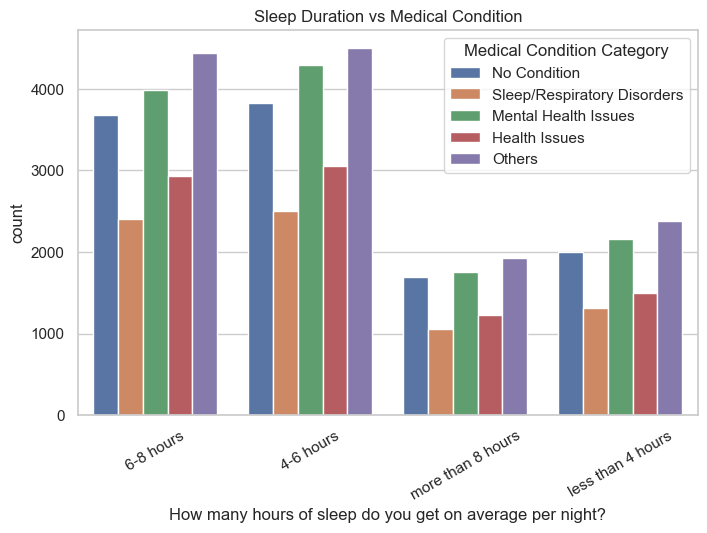

In [59]:
plt.figure(figsize=(8,5))
sns.countplot(x='How many hours of sleep do you get on average per night?', 
              hue='Medical Condition Category', data=df)
plt.title("Sleep Duration vs Medical Condition")
plt.xticks(rotation=30)
plt.show()

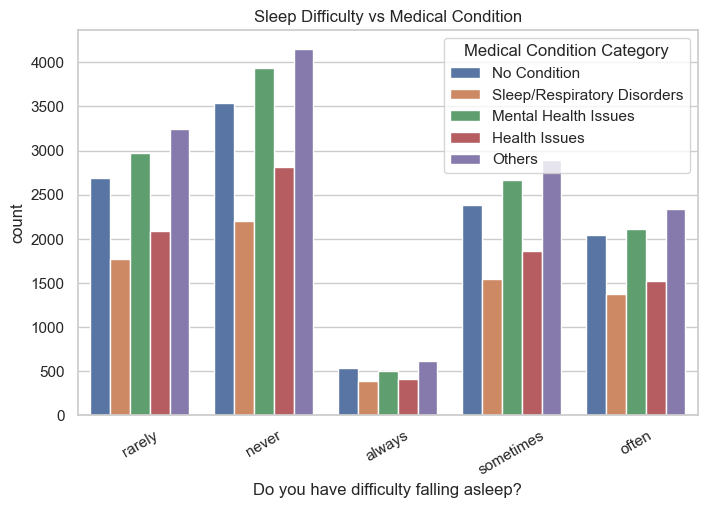

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(x='Do you have difficulty falling asleep?', 
              hue='Medical Condition Category', data=df)
plt.title("Sleep Difficulty vs Medical Condition")
plt.xticks(rotation=30)
plt.show()

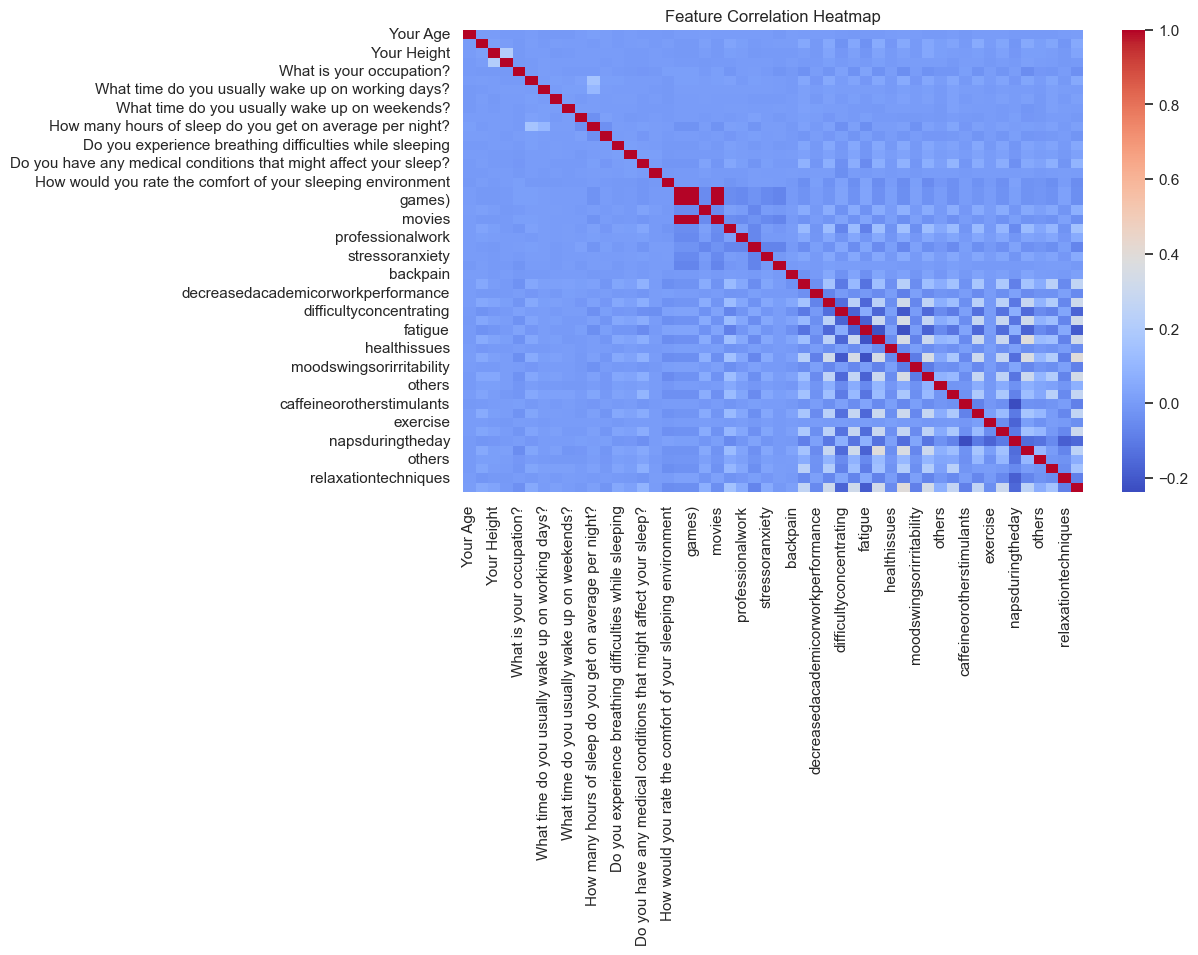

In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()